## Exercise 1.1

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from scipy.stats import norm
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

plt.style.use('default')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

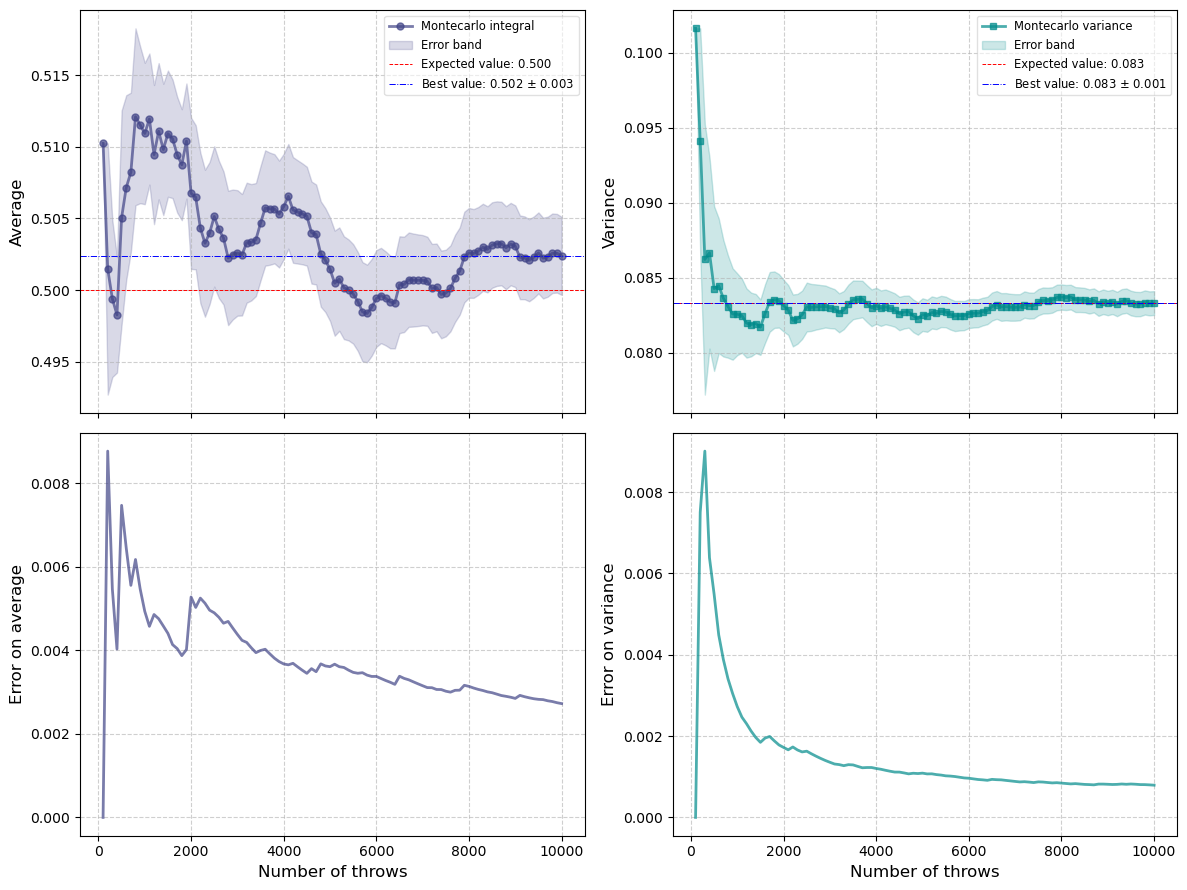

In [26]:
file_avg = "Exercise_1_1/output_average.data"
x1, y1, error1 = np.loadtxt(file_avg, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x3, y3 = np.loadtxt(file_avg, usecols=(0, 2), delimiter='\t', unpack=True)

file_var = "Exercise_1_1/output_variance.data"
x2, y2, error2 = np.loadtxt(file_var, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x4, y4 = np.loadtxt(file_var, usecols=(0, 2), delimiter='\t', unpack=True)

viridis = plt.cm.viridis
color_avg = viridis(0.2)
color_var = 'darkcyan'

fig, axs = plt.subplots(2, 2, figsize=(12, 9))

# Media
axs[0, 0].plot(x1, y1, 'o-', color=color_avg, alpha=0.7, markersize=5, label='Montecarlo integral')

axs[0, 0].fill_between(x1, y1 - error1, y1 + error1,
                       color=color_avg, alpha=0.2, label='Error band')

axs[0, 0].axhline(y=0.5, color='red', linestyle='--', linewidth=0.7,
                 label=f'Expected value: {1./2.:.3f}')

axs[0, 0].axhline(y=y1[99], color='blue', linestyle='-.', linewidth=0.7,
                 label=rf'Best value: {y1[99]:.3f} $\pm$ {error1[99]:.3f}')
axs[0, 0].set_ylabel('Average')
axs[0, 0].legend(loc='upper right', frameon=True, fancybox=True,
                 facecolor='white', framealpha=0.6, fontsize='small')
axs[0, 0].grid(True, alpha=0.6, linestyle='--')
axs[0, 0].tick_params(axis='x', labelbottom=False)

# Varianza
axs[0, 1].plot(x2, y2, 's-', color=color_var, alpha=0.7, markersize=5,label='Montecarlo variance')

axs[0, 1].fill_between(x2, y2 - error2, y2 + error2,
                       color=color_var, alpha=0.2, label='Error band')

axs[0, 1].axhline(y=1./12., color='red', linestyle='--', linewidth=0.7,
                 label=f'Expected value: {1./12.:.3f}')

axs[0, 1].axhline(y=y2[99], color='blue', linestyle='-.', linewidth=0.7,
                 label=rf'Best value: {y2[99]:.3f} $\pm$ {error2[99]:.3f}')
axs[0, 1].set_ylabel('Variance')
axs[0, 1].legend(loc='upper right', frameon=True, fancybox=True,
                 facecolor='white', framealpha=0.6, fontsize='small')
axs[0, 1].grid(True, alpha=0.6, linestyle='--')
axs[0, 1].tick_params(axis='x', labelbottom=False)

# Errore sulla media (linea)
axs[1, 0].plot(x3, y3, '-', color=color_avg, alpha=0.7)
axs[1, 0].set_xlabel('Number of throws')
axs[1, 0].set_ylabel('Error on average')
axs[1, 0].grid(True, alpha=0.6, linestyle='--')

# Errore sulla varianza (linea)
axs[1, 1].plot(x4, y4, '-', color=color_var, alpha=0.7)
axs[1, 1].set_xlabel('Number of throws')
axs[1, 1].set_ylabel('Error on variance')
axs[1, 1].grid(True, alpha=0.6, linestyle='--')

# Layout finale
plt.tight_layout()
plt.show()


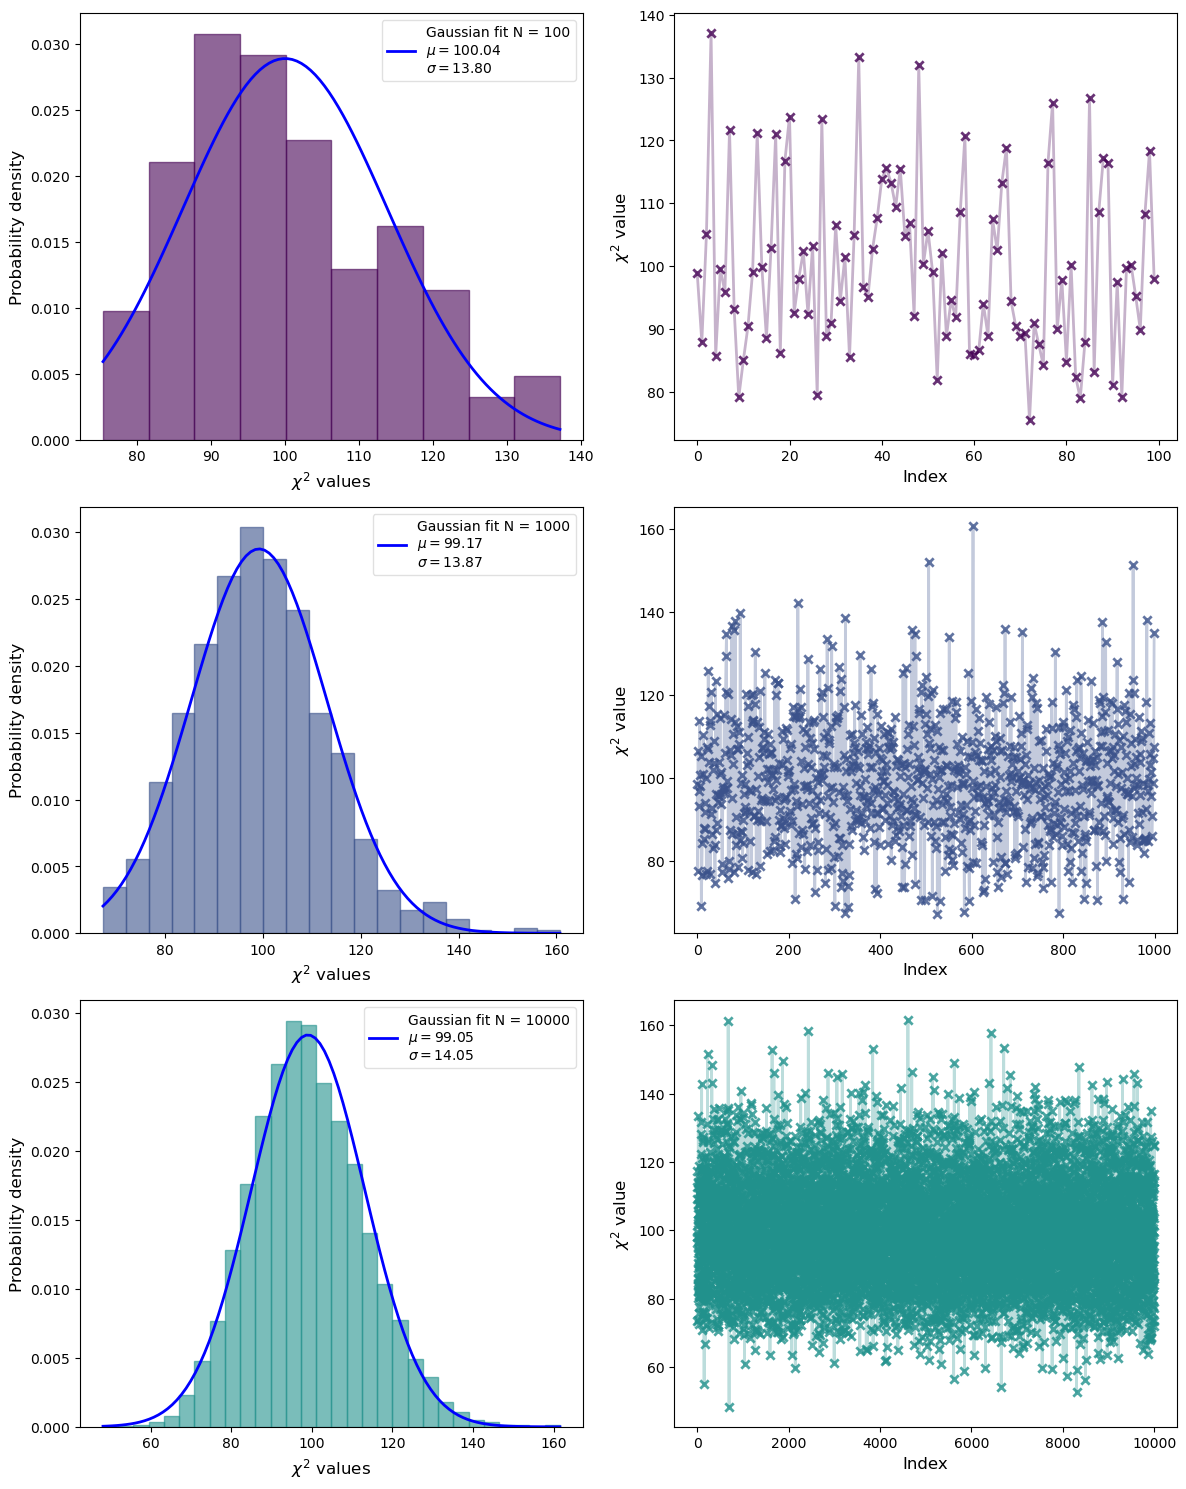

In [21]:
def read_data(file):
    with open(file, 'r') as f:
        data = [float(line.strip()) for line in f]
    return data

def plot_data(file_counts, file_chi, ax_index, title, color, bins):
    data_counts = read_data(file_counts)
    data_chi = read_data(file_chi)
    mu, sigma = norm.fit(data_chi) 

    axs[ax_index, 0].hist(
        data_chi, bins=bins, color=color, alpha=0.6, edgecolor=color, density=True
    )
    axs[ax_index, 0].set_xlabel('$\\chi^2$ values')
    axs[ax_index, 0].set_ylabel('Probability density')
    x_vals = np.linspace(np.min(data_chi), np.max(data_chi), 100)
    y_vals = norm.pdf(x_vals, mu, sigma)
    axs[ax_index, 0].plot(
        x_vals, y_vals,linestyle='-', color='b', 
        label=f'Gaussian fit {title}\n$\\mu = {mu:.2f}$\n$\\sigma = {sigma:.2f}$'
    )
    axs[ax_index, 0].legend(loc='upper right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6)

    axs[ax_index, 1].scatter(
        range(len(data_chi)), data_chi, color=color, marker='x', alpha=0.8
    )
    axs[ax_index, 1].plot(
        range(len(data_chi)), data_chi, linestyle='-', color=color, alpha=0.3
    )
    axs[ax_index, 1].set_xlabel('Index')
    axs[ax_index, 1].set_ylabel('$\\chi^2$ value')


fig, axs = plt.subplots(3, 2, figsize=(12, 15))
files = [
    ('Exercise_1_1/output_counts_100.data', 'Exercise_1_1/output_chi_100.data', 'N = 100', 10),
    ('Exercise_1_1/output_counts_1000.data', 'Exercise_1_1/output_chi_1000.data', 'N = 1000', 20),
    ('Exercise_1_1/output_counts_10000.data', 'Exercise_1_1/output_chi_10000.data', 'N = 10000', 30)
]
viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(files)+2))
hex_colors = [mcolors.to_hex(c) for c in viridis_colors]

for i, (file_counts, file_chi, title, bins) in enumerate(files):
    plot_data(file_counts, file_chi, i, title, hex_colors[i], bins)

plt.tight_layout()
plt.show()


# Exercise 1.2

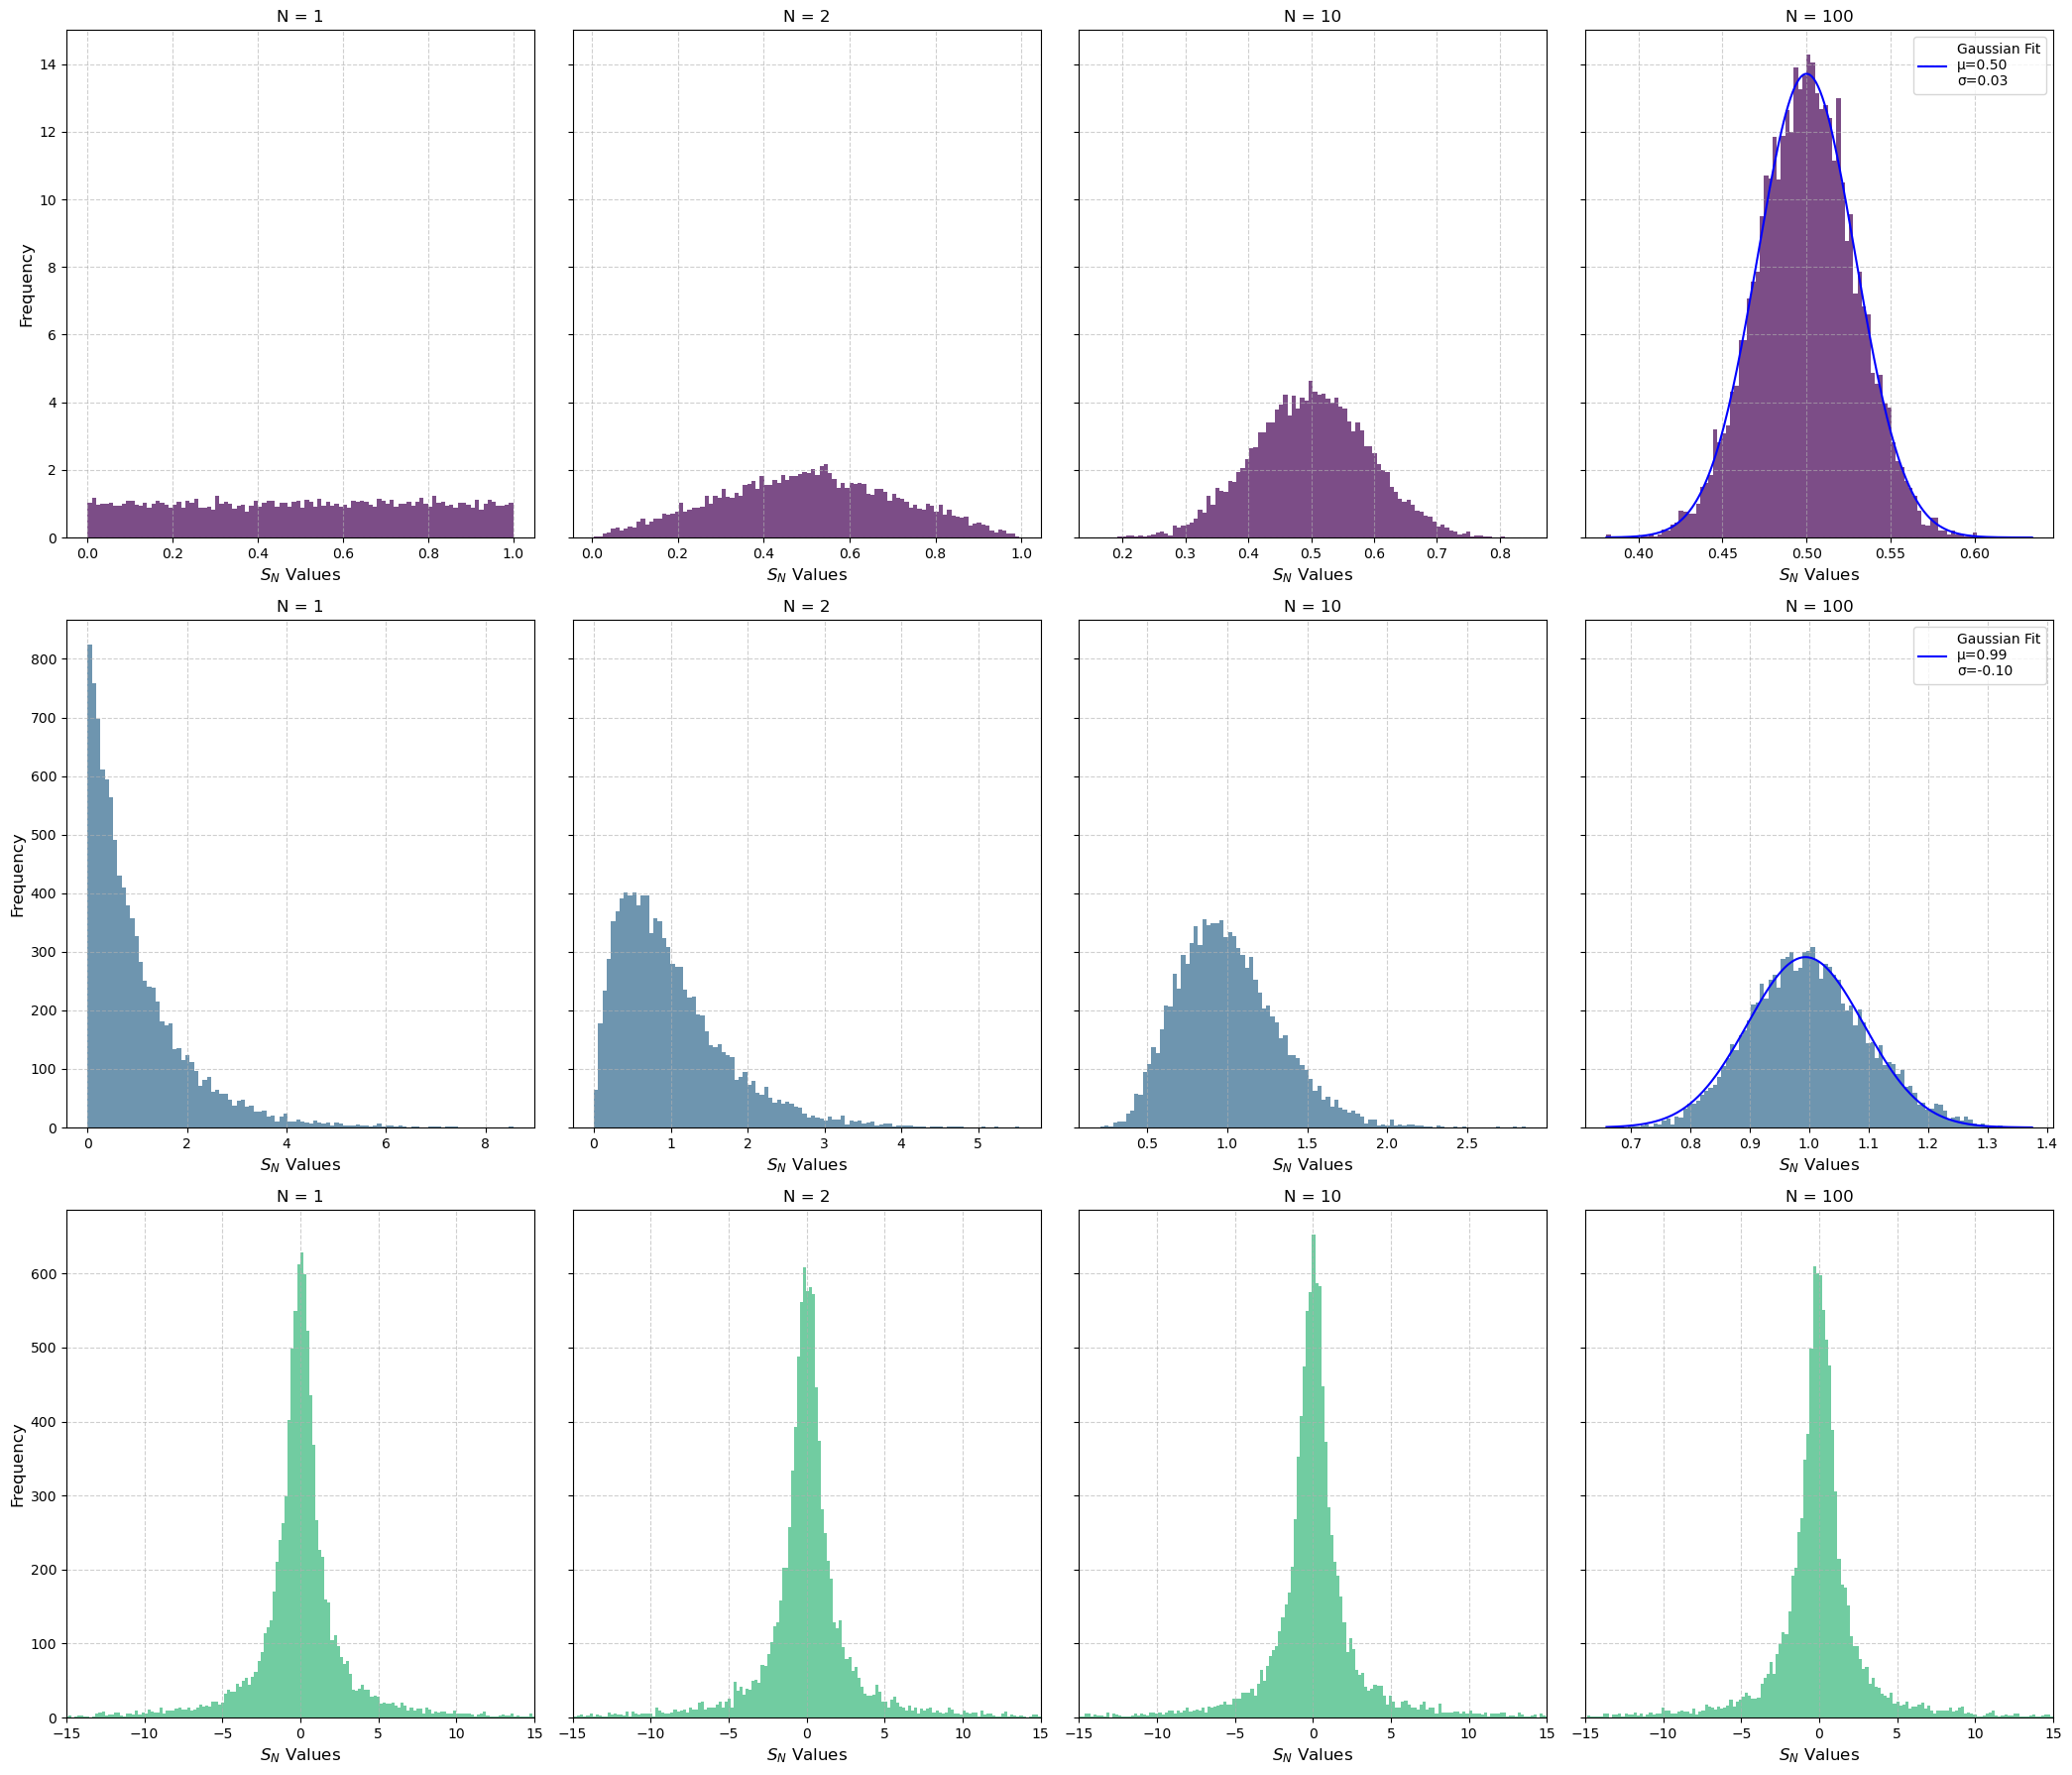

In [27]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

filenames = {
    "1": "Exercise_1_2/output_N1.txt",
    "2": "Exercise_1_2/output_N2.txt",
    "10": "Exercise_1_2/output_N10.txt",
    "100": "Exercise_1_2/output_N100.txt"
}

# Generate 3 distinct colors (one per row) to avoid index confusion
row_colors = plt.cm.viridis(np.linspace(0, 1, 4))
row_hex = [mcolors.to_hex(c) for c in row_colors]

fig, axs = plt.subplots(3, 4, figsize=(21, 18), sharey='row')

for idx, (N_label, filename) in enumerate(filenames.items()):
    try:
        data = np.loadtxt(filename, skiprows=1)

        # Plot first column (row 0)
        hist_data, bins, _ = axs[0, idx].hist(data[:, 0], bins=100, alpha=0.7, color=row_hex[0], density=True)
        axs[0, idx].set_xlabel("$S_N$ Values")
        axs[0, 0].set_ylabel("Frequency")
        axs[0, idx].set_title(f"N = {N_label}")
        axs[0, idx].grid(True, alpha=0.6, linestyle='--')

        # Fit Gaussian for N=100 (first column)
        if N_label == "100":
            bin_centers = (bins[:-1] + bins[1:]) / 2
            popt, _ = curve_fit(gaussian, bin_centers, hist_data,
                                p0=[1, np.mean(data[:, 0]), np.std(data[:, 0])])
            x = np.linspace(min(data[:, 0]), max(data[:, 0]), 200)
            # Use Unicode μ and σ to avoid backslash-escape warnings
            axs[0, idx].plot(x, gaussian(x, *popt), color='b', lw=1.5,
                             label=f'Gaussian Fit\nμ={popt[1]:.2f}\nσ={popt[2]:.2f}')
            axs[0, idx].legend()

        # Plot second column (row 1)
        hist_data, bins, _ = axs[1, idx].hist(data[:, 1], bins=100, alpha=0.7, color=row_hex[1])
        axs[1, idx].set_xlabel("$S_N$ Values")
        axs[1, 0].set_ylabel("Frequency")
        axs[1, idx].set_title(f"N = {N_label}")
        axs[1, idx].grid(True, alpha=0.6, linestyle='--')

        # Fit Gaussian for N=100 (second column)
        if N_label == "100":
            bin_centers = (bins[:-1] + bins[1:]) / 2
            popt, _ = curve_fit(gaussian, bin_centers, hist_data,
                                p0=[1, np.mean(data[:, 1]), np.std(data[:, 1])])
            x = np.linspace(min(data[:, 1]), max(data[:, 1]), 200)
            axs[1, idx].plot(x, gaussian(x, *popt), color='b', lw=1.5,
                             label=f'Gaussian Fit\nμ={popt[1]:.2f}\nσ={popt[2]:.2f}')
            axs[1, idx].legend()

        # Plot third column (row 2)
        filtered_data = data[:, 2][(data[:, 2] >= -50) & (data[:, 2] <= 50)]
        axs[2, idx].hist(filtered_data, bins=500, alpha=0.7, color=row_hex[2])
        axs[2, idx].set_xlabel("$S_N$ Values")
        axs[2, 0].set_ylabel("Frequency")
        axs[2, idx].set_xlim(-15., 15.)
        axs[2, idx].set_title(f"N = {N_label}")
        axs[2, idx].grid(True, alpha=0.6, linestyle='--')

    except Exception as e:
        print(f"Error processing {filename}: {e}")

plt.tight_layout()
plt.show()


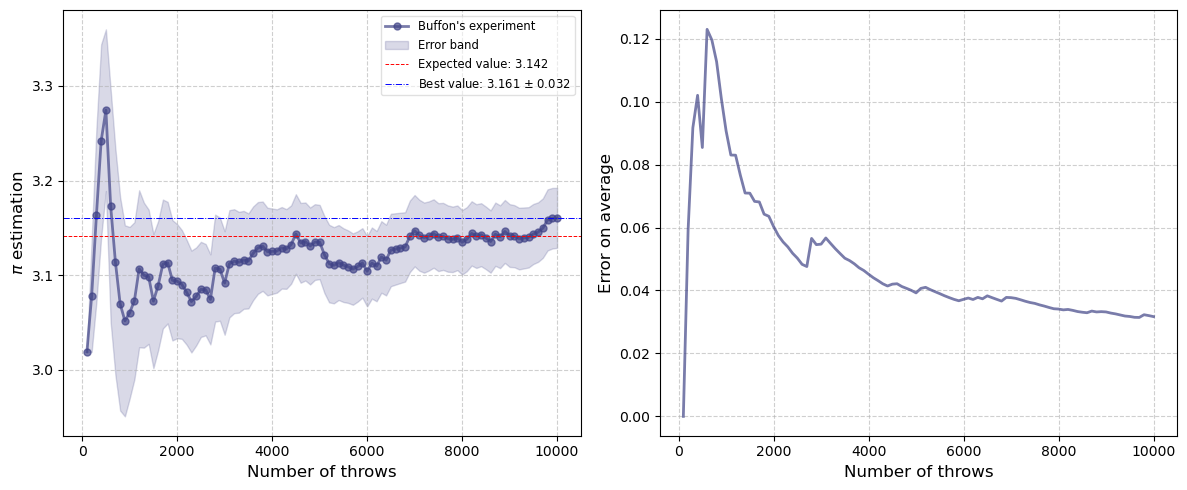

In [25]:
file1 = "Exercise_1_3/output_average.data"
x1, y1, error1 = np.loadtxt(file1, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x2, y2 = np.loadtxt(file1, usecols=(0, 2), delimiter='\t', unpack=True)

# Viridis color
viridis = plt.cm.viridis
color_std = viridis(0.2)  
color_err = viridis(0.2)
ref_color = viridis(0.1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x1, y1, 'o-', color=color_std, markersize=5, alpha=0.7, label="Buffon's experiment")

axes[0].fill_between(x1, y1 - error1, y1 + error1,
                     color=color_std, alpha=0.2, label='Error band')

axes[0].axhline(y=np.pi, color='red', linestyle='--', linewidth=0.7,
                label=rf'Expected value: {np.pi:.3f}')

axes[0].axhline(y=y1[99], color='blue', linestyle='-.', linewidth=0.7,
                label=rf'Best value: {y1[99]:.3f} $\pm$ {error1[99]:.3f}')

axes[0].set_xlabel('Number of throws')
axes[0].set_ylabel(r'$\pi$ estimation')
axes[0].legend(loc='upper right', frameon=True, fancybox=True,
               facecolor='white', framealpha=0.6, fontsize='small')
axes[0].grid(True, alpha=0.6, linestyle='--')

axes[1].plot(x2, y2, '-', color=color_err, alpha=0.7, label='Error')
axes[1].set_xlabel('Number of throws')
axes[1].set_ylabel('Error on average')
axes[1].grid(True, alpha=0.6, linestyle='--')

plt.tight_layout()
plt.show()
